In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

data = load_iris()
X = data.data
y_true = data.target
k = len(np.unique(y_true))


In [9]:
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)


In [10]:
hclust = AgglomerativeClustering(n_clusters=k, linkage='ward')
y_hier = hclust.fit_predict(X)


In [11]:
sil_kmeans = silhouette_score(X, y_kmeans)
sil_hier = silhouette_score(X, y_hier)

ari_kmeans = adjusted_rand_score(y_true, y_kmeans)
ari_hier = adjusted_rand_score(y_true, y_hier)

print("Silhouette Score (K-Means):", sil_kmeans)
print("Silhouette Score (Hierarchical):", sil_hier)
print("ARI (K-Means):", ari_kmeans)
print("ARI (Hierarchical):", ari_hier)


Silhouette Score (K-Means): 0.5528190123564095
Silhouette Score (Hierarchical): 0.5543236611296419
ARI (K-Means): 0.7302382722834697
ARI (Hierarchical): 0.7311985567707746


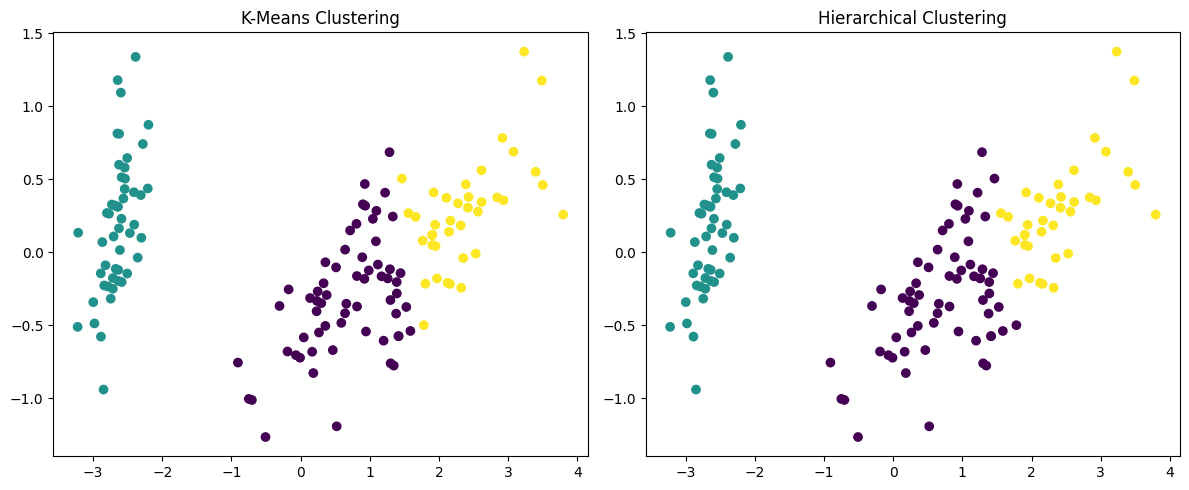

In [12]:
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("K-Means Clustering")
plt.scatter(X_2D[:,0], X_2D[:,1], c=y_kmeans, cmap='viridis')

plt.subplot(1,2,2)
plt.title("Hierarchical Clustering")
plt.scatter(X_2D[:,0], X_2D[:,1], c=y_hier, cmap='viridis')

plt.tight_layout()
plt.show()
